In [4]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import os

# Force working directory to repo root
os.chdir("/scratch2/ij292/tnp-crps")

## Sawtooth Interpolation Gate Dropout Table

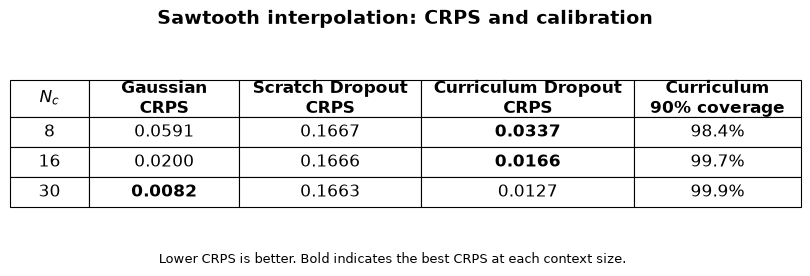

Saved: results/synthetic_1d/sawtooth_interpolation_gate_dropout_curriculum/sawtooth_crps_calibration_table.pdf


In [1]:

# ---------------------------------------------------------------------
# Output
# ---------------------------------------------------------------------
output_dir = Path(
    "results/synthetic_1d/"
    "sawtooth_interpolation_gate_dropout_curriculum"
)
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "sawtooth_crps_calibration_table.pdf"

if output_path.exists():
    raise FileExistsError(
        f"Refusing to overwrite existing file: {output_path}"
    )


# ---------------------------------------------------------------------
# Table data
# ---------------------------------------------------------------------
columns = [
    r"$N_c$",
    "Gaussian\nCRPS",
    "Scratch Dropout\nCRPS",
    "Curriculum Dropout\nCRPS",
    "Curriculum\n90% coverage",
]

rows = [
    ["8",  "0.0591", "0.1667", "0.0337", "98.4%"],
    ["16", "0.0200", "0.1666", "0.0166", "99.7%"],
    ["30", "0.0082", "0.1663", "0.0127", "99.9%"],
]


# ---------------------------------------------------------------------
# Figure
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10.2, 2.6))
ax.axis("off")

table = ax.table(
    cellText=rows,
    colLabels=columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.10, 0.19, 0.23, 0.27, 0.21],
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.0, 1.8)


# ---------------------------------------------------------------------
# Formatting
# ---------------------------------------------------------------------
for (row_idx, col_idx), cell in table.get_celld().items():
    cell.set_linewidth(0.8)

    if row_idx == 0:
        cell.set_text_props(weight="bold")
        cell.set_height(cell.get_height() * 1.25)

# Bold the lowest CRPS value at each context size:
# Nc=8  -> curriculum
# Nc=16 -> curriculum
# Nc=30 -> Gaussian
table[(1, 3)].set_text_props(weight="bold")
table[(2, 3)].set_text_props(weight="bold")
table[(3, 1)].set_text_props(weight="bold")


ax.set_title(
    "Sawtooth interpolation: CRPS and calibration",
    fontsize=14,
    fontweight="bold",
    pad=14,
)

fig.text(
    0.5,
    0.035,
    "Lower CRPS is better. Bold indicates the best CRPS at each context size.",
    ha="center",
    fontsize=9,
)

plt.savefig(
    output_path,
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.12,
)

plt.show()

print(f"Saved: {output_path}")

## Fixed Context Evaluation

In [5]:
paths = {
    "Dropout, train Nc=64": Path(
        "results/sawtooth/ar_nc64_metrics_v1/"
        "sawtooth_ar_summary.csv"
    ),
    "Dropout, train Nc=96": Path(
        "results/sawtooth/ar_nc96_metrics_v1/"
        "sawtooth_ar_summary.csv"
    ),
    "Dropout vs StochLN, train Nc=128": Path(
        "results/sawtooth/ar_nc128_models_metrics_v1/"
        "sawtooth_ar_summary.csv"
    ),
}


In [6]:
frames = []

for experiment, path in paths.items():
    if not path.is_file():
        raise FileNotFoundError(path)

    frame = pd.read_csv(path)
    frame.insert(0, "experiment", experiment)
    frames.append(frame)

combined = pd.concat(
    frames,
    ignore_index=True,
)

columns = [
    "experiment",
    "nc",
    "source",
    "num_tasks",
    "rmse",
    "crps",
    "energy",
    "coverage90",
    "coverage95",
    "width90",
    "width95",
    "runtime_s_per_task",
]

display(
    combined[columns].sort_values(
        ["nc", "source"]
    )
)

,experiment,nc,source,num_tasks,rmse,crps,energy,coverage90,coverage95,width90,width95,runtime_s_per_task
0,"Dropout, train Nc=64",48,"Dropout CRPS, train Nc=64",4096,0.078370,0.013146,0.124174,0.991455,0.995712,0.130156,0.151994,0.044164
1,"Dropout, train Nc=64",48,"Trivial U(0,1)",4096,0.291859,0.166878,0.808265,0.863663,0.913010,0.864979,0.912934,0.000000
2,"Dropout, train Nc=96",80,"Dropout CRPS, train Nc=96",4096,0.066947,0.009817,0.092317,0.992325,0.995956,0.098305,0.114776,0.073065
3,"Dropout, train Nc=96",80,"Trivial U(0,1)",4096,0.291435,0.166726,0.807007,0.865555,0.913223,0.864979,0.912934,0.000000
4,"Dropout vs StochLN, train Nc=128",112,"Dropout CRPS, train Nc=128",4096,0.061099,0.008125,0.078048,0.993210,0.996262,0.083289,0.097197,0.094672
5,"Dropout vs StochLN, train Nc=128",112,"StochLN CRPS, train Nc=128",4096,0.291759,0.166731,0.807565,0.872238,0.929413,0.873060,0.939661,0.096992
6,"Dropout vs StochLN, train Nc=128",112,"Trivial U(0,1)",4096,0.291274,0.166422,0.806364,0.865128,0.913940,0.864979,0.912934,0.000000
